In [1]:
pip install xgboost shap Boruta

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
from boruta import BorutaPy
from sklearn.preprocessing import LabelEncoder
import warnings

# Suppress warnings for cleaner console output
warnings.filterwarnings('ignore')

print("🚀 Starting the Biological Feature Selection Pipeline...")

# ==========================================
# PHASE 0: DATA LOADING & PREPARATION (CLR)
# ==========================================
print("\n[Phase 0] Loading Data & Applying CLR Transformation...")
df_merged = pd.read_csv('/Users/pawanpahune/AI_Pipeline_Metagenomics/merging_pipeline/Merged_Taxa_Metadata.csv')

# Separate Features and Target
X_raw = df_merged.drop(columns=['Code', 'Target_Crop_Grouped'])
y_raw = df_merged['Target_Crop_Grouped']

# Encode target labels to strict 0, 1, 2... format for XGBoost
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

# Apply Half-Min Rule and CLR Transformation
min_non_zero = X_raw[X_raw > 0].min().min()
pseudo_count = min_non_zero / 2
X_pseudo = X_raw + pseudo_count
geom_mean = np.exp(np.mean(np.log(X_pseudo), axis=1))
X_clr = np.log(X_pseudo.div(geom_mean, axis=0))

print(f"Initial Feature Count: {X_clr.shape[1]} Microbes")

# ==========================================
# PHASE 1: THE COLLINEARITY PURGE
# ==========================================
print("\n[Phase 1] Purging Redundant/Collinear Microbes...")
# Calculate Spearman correlation matrix
corr_matrix = X_clr.corr(method='spearman').abs()

# Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation greater than 0.85
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]
X_phase1 = X_clr.drop(columns=to_drop)

print(f"Dropped {len(to_drop)} highly correlated microbes.")
print(f"Features remaining: {X_phase1.shape[1]}")

# ==========================================
# PHASE 2: BORUTA (WITH DYNAMIC RESCUE POOL)
# ==========================================
print("\n[Phase 2] Running Boruta Algorithm to eliminate statistical noise...")

xgb_boruta = xgb.XGBClassifier(
    max_depth=3, 
    learning_rate=0.05,
    n_estimators=100, 
    random_state=42, 
    n_jobs=-1
)

# Setup Boruta
boruta_selector = BorutaPy(
    xgb_boruta, 
    n_estimators='auto', 
    verbose=0, 
    random_state=42, 
    max_iter=50 
)

boruta_selector.fit(X_phase1.values, y)

# Extract Strong and Tentative features
boruta_strong = X_phase1.columns[boruta_selector.support_].tolist()
boruta_tentative = X_phase1.columns[boruta_selector.support_weak_].tolist()
combined_boruta = list(set(boruta_strong + boruta_tentative))

# ---------------------------------------------------------
# THE FIX: Dynamic Rescue Pool if Boruta is too aggressive
# ---------------------------------------------------------
target_feature_count = 15

if len(combined_boruta) <= target_feature_count:
    print(f"⚠️ Boruta only validated {len(combined_boruta)} microbes. Activating Dynamic Rescue Pool...")
    
    # Train a quick baseline model on the full Phase 1 data
    xgb_baseline = xgb.XGBClassifier(max_depth=3, random_state=42, n_jobs=-1)
    xgb_baseline.fit(X_phase1, y)
    
    # Get standard feature importances
    importances = pd.Series(xgb_baseline.feature_importances_, index=X_phase1.columns)
    
    # Grab the top 40 microbes to ensure SHAP-RFE has a healthy pool to work with
    top_baseline_features = importances.sort_values(ascending=False).head(40).index.tolist()
    
    # Combine Boruta winners with the baseline top performers
    pool_features = list(set(combined_boruta + top_baseline_features))
    X_phase2 = X_phase1[pool_features]
    print(f"Rescue Pool created with {X_phase2.shape[1]} candidate microbes.")
else:
    X_phase2 = X_phase1[combined_boruta]
    print(f"Features remaining after Boruta: {X_phase2.shape[1]}")

# ==========================================
# PHASE 3: SHAP-GUIDED RECURSIVE ELIMINATION
# ==========================================
print("\n[Phase 3] Running SHAP-RFE to isolate the top 15 Elite Microbes...")

current_features = list(X_phase2.columns)
xgb_shap = xgb.XGBClassifier(
    max_depth=3, 
    learning_rate=0.05, 
    n_estimators=100, 
    random_state=42, 
    n_jobs=-1
)

# If we somehow have fewer than 15 features, skip the loop. Otherwise, recursively drop.
if len(current_features) > target_feature_count:
    while len(current_features) > target_feature_count:
        # Train model on current subset
        X_subset = X_phase2[current_features]
        xgb_shap.fit(X_subset, y)
        
        # Calculate SHAP values
        explainer = shap.TreeExplainer(xgb_shap)
        shap_values = explainer.shap_values(X_subset)
        
        # Handle SHAP output dimensions safely
        if isinstance(shap_values, list):
            shap_sum = np.zeros(X_subset.shape[1])
            for sv in shap_values:
                shap_sum += np.abs(sv).mean(axis=0)
        elif len(shap_values.shape) == 3:
            shap_sum = np.abs(shap_values).mean(axis=(0, 2))
        else:
            shap_sum = np.abs(shap_values).mean(axis=0)
            
        # Find and drop the weakest feature
        least_important_idx = np.argmin(shap_sum)
        feature_to_drop = current_features[least_important_idx]
        current_features.remove(feature_to_drop)

print(f"\n🎯 SHAP-RFE Complete! The Elite {len(current_features)} Microbes have been identified:")
for i, feature in enumerate(current_features, 1):
    print(f"  {i}. {feature}")
# ==========================================
# PHASE 4: EXPORT TO COMPRESSED DF
# ==========================================
print("\n[Phase 4] Creating Final Dataset...")

# Create the final dataframe with the 15 elite features
final_df = X_clr[current_features].copy()

# Add the Original Target column back
# (Using the original text names, not the encoded numbers, for readability)
final_df['Target_Crop_Grouped'] = y_raw.values 

# Save to CSV
output_filename = 'compressed_df.csv'
final_df.to_csv(output_filename, index=False)

print(f"✅ SUCCESS: File saved locally as '{output_filename}'")
print(f"Final Data Shape: {final_df.shape[0]} samples, {final_df.shape[1]} columns (15 microbes + 1 target)")

🚀 Starting the Biological Feature Selection Pipeline...

[Phase 0] Loading Data & Applying CLR Transformation...
Initial Feature Count: 42 Microbes

[Phase 1] Purging Redundant/Collinear Microbes...
Dropped 4 highly correlated microbes.
Features remaining: 38

[Phase 2] Running Boruta Algorithm to eliminate statistical noise...
⚠️ Boruta only validated 7 microbes. Activating Dynamic Rescue Pool...
Rescue Pool created with 38 candidate microbes.

[Phase 3] Running SHAP-RFE to isolate the top 15 Elite Microbes...

🎯 SHAP-RFE Complete! The Elite 15 Microbes have been identified:
  1. Aspergillus terreus
  2. Fusarium brachygibbosum
  3. Solirubrobacter sp.
  4. Udaeobacter sp.
  5. Gemmata sp.
  6. Talaromyces marneffei
  7. Ilumatobacter sp.
  8. Curvularia lunata
  9. Humicola olivacea
  10. Humicola sp.
  11. Rhodoplanes sp.
  12. Nitrosocosmicus sp.
  13. Scytalidium sp.
  14. Rubrobacter sp.
  15. Neobacillus drentensis

[Phase 4] Creating Final Dataset...
✅ SUCCESS: File saved local

📂 Loading the Elite 15-Feature Dataset...
✅ Data Ready: Training on 15 features.
🔐 Authenticating with DagsHub...


2026/06/06 04:02:01 INFO mlflow.tracking.fluent: Experiment with name 'Elastic_Net_Elite_15_Features' does not exist. Creating a new experiment.


🚀 Starting Grid Search (Tuning C and L1 Ratio)...
Fitting 5 folds for each of 35 candidates, totalling 175 fits


2026/06/06 04:02:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/06 04:02:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/06 04:02:29 INFO mlflow.sklearn.utils: Logging the 5 best runs, 30 runs will be omitted.


🏃 View run resilient-crane-536 at: https://dagshub.com/PAWANPAHUNE/AI-Metagenomic-Pipeline-CIAT-Intern-.mlflow/#/experiments/3/runs/23429f80d02643278f033bc6d036bb86
🧪 View experiment at: https://dagshub.com/PAWANPAHUNE/AI-Metagenomic-Pipeline-CIAT-Intern-.mlflow/#/experiments/3
🏃 View run invincible-squid-489 at: https://dagshub.com/PAWANPAHUNE/AI-Metagenomic-Pipeline-CIAT-Intern-.mlflow/#/experiments/3/runs/fcb017aba3e742c5a5e1778b75f13b88
🧪 View experiment at: https://dagshub.com/PAWANPAHUNE/AI-Metagenomic-Pipeline-CIAT-Intern-.mlflow/#/experiments/3
🏃 View run bittersweet-flea-930 at: https://dagshub.com/PAWANPAHUNE/AI-Metagenomic-Pipeline-CIAT-Intern-.mlflow/#/experiments/3/runs/6cea64fdfdea4477b1e5c496b4d35a66
🧪 View experiment at: https://dagshub.com/PAWANPAHUNE/AI-Metagenomic-Pipeline-CIAT-Intern-.mlflow/#/experiments/3
🏃 View run bright-auk-856 at: https://dagshub.com/PAWANPAHUNE/AI-Metagenomic-Pipeline-CIAT-Intern-.mlflow/#/experiments/3/runs/9cf327f17000410390876e93a16ceabf
🧪

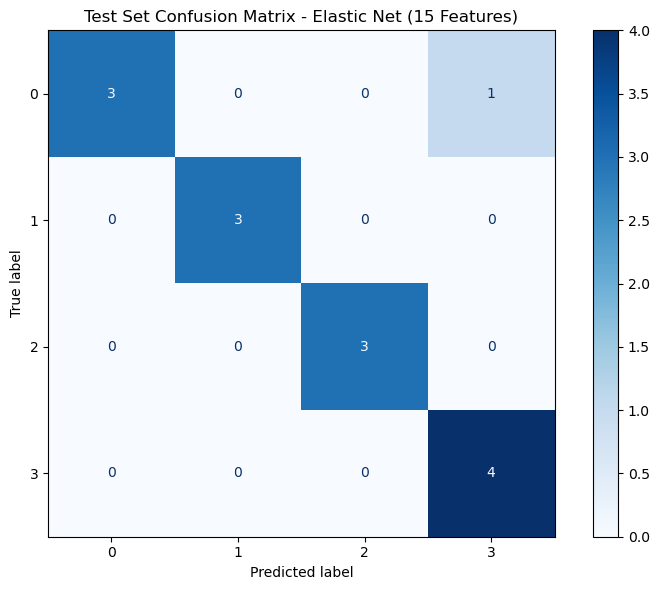

🏃 View run ElasticNet_15_Features_Corrected at: https://dagshub.com/PAWANPAHUNE/AI-Metagenomic-Pipeline-CIAT-Intern-.mlflow/#/experiments/3/runs/87b75e5f6abe4070b95f4397bd356b54
🧪 View experiment at: https://dagshub.com/PAWANPAHUNE/AI-Metagenomic-Pipeline-CIAT-Intern-.mlflow/#/experiments/3

✅ Execution Complete! Check DagsHub to view the results.


🏃 View run sincere-mule-643 at: https://dagshub.com/PAWANPAHUNE/AI-Metagenomic-Pipeline-CIAT-Intern-.mlflow/#/experiments/3/runs/8772a3dd9bc34687b7f59a940a5b8eab
🧪 View experiment at: https://dagshub.com/PAWANPAHUNE/AI-Metagenomic-Pipeline-CIAT-Intern-.mlflow/#/experiments/3
🏃 View run wise-whale-161 at: https://dagshub.com/PAWANPAHUNE/AI-Metagenomic-Pipeline-CIAT-Intern-.mlflow/#/experiments/3/runs/5b638219d02640d5a40f505b675cf568
🧪 View experiment at: https://dagshub.com/PAWANPAHUNE/AI-Metagenomic-Pipeline-CIAT-Intern-.mlflow/#/experiments/3
🏃 View run righteous-pig-630 at: https://dagshub.com/PAWANPAHUNE/AI-Metagenomic-Pipeline-CIAT-Intern-.mlflow/#/experiments/3/runs/f28a4d3df8d34e03a7ad236c046f38ea
🧪 View experiment at: https://dagshub.com/PAWANPAHUNE/AI-Metagenomic-Pipeline-CIAT-Intern-.mlflow/#/experiments/3
🏃 View run treasured-sow-313 at: https://dagshub.com/PAWANPAHUNE/AI-Metagenomic-Pipeline-CIAT-Intern-.mlflow/#/experiments/3/runs/8ef287f14cf6409cb9117c2d4e81c092
🧪 View exp

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, f1_score, precision_score, 
                             recall_score, balanced_accuracy_score, 
                             confusion_matrix, ConfusionMatrixDisplay, make_scorer)

import mlflow
import mlflow.sklearn

# Suppress minor convergence warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. DATA PREPARATION (Strictly for Pre-Encoded Data)
# ==========================================
print("📂 Loading the Elite 15-Feature Dataset...")

df_compressed = pd.read_csv('/Users/pawanpahune/AI_Pipeline_Metagenomics/df_compression/compressed_df.csv')

# Separate features and target
X = df_compressed.drop(columns=['Target_Crop_Grouped'])

# FIX: Force as integer, strictly NO LabelEncoder used here.
y = df_compressed['Target_Crop_Grouped'].astype(int).values.ravel()

# Stratified Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.5, 
    random_state=42, 
    stratify=y  
)

print(f"✅ Data Ready: Training on {X_train.shape[1]} features.")

# ==========================================
# 2. DAGSHUB AUTH & MLFLOW SETUP
# ==========================================
print("🔐 Authenticating with DagsHub...")
os.environ["MLFLOW_TRACKING_USERNAME"] = os.getenv("MLFLOW_USERNAME")
os.environ["MLFLOW_TRACKING_PASSWORD"] = os.getenv("MLFLOW_TRACKING_PASSWORD")

TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI")
mlflow.set_tracking_uri(TRACKING_URI)
mlflow.set_experiment("Elastic_Net_Elite_15_Features")

# Enable Autologging for nested parameter tracking
mlflow.sklearn.autolog(log_models=True, log_input_examples=True)

# ==========================================
# 3. ELASTIC NET PIPELINE & OPTIMIZED GRID SEARCH
# ==========================================
pipeline = Pipeline([
    ('scaler', StandardScaler()), 
    ('clf', LogisticRegression(
        penalty='elasticnet', 
        solver='saga', 
        max_iter=10000, # Increased max_iter to ensure mathematical convergence
        random_state=42,
        class_weight='balanced'
    ))
])

# FIX: An optimized, finer grid specifically designed for low-dimensional data (15 features)
param_grid = {
    'clf__C': [0.001, 0.01, 0.1, 1.0, 10.0], # Finer regularization strengths
    'clf__l1_ratio': [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0] # Granular L1/L2 mixing
}

# Define rigorous scoring metrics
scoring_metrics = {
    'accuracy': make_scorer(accuracy_score),
    'f1_weighted': make_scorer(f1_score, average='weighted'),
    'precision': make_scorer(precision_score, average='weighted', zero_division=0),
    'recall': make_scorer(recall_score, average='weighted'),
    'balanced_acc': make_scorer(balanced_accuracy_score)
}

# 5-Fold Stratified Cross Validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring=scoring_metrics,
    refit='f1_weighted', 
    return_train_score=True,
    n_jobs=-1,
    verbose=1
)

# ==========================================
# 4. TRAINING & EVALUATION
# ==========================================
print("🚀 Starting Grid Search (Tuning C and L1 Ratio)...")

with mlflow.start_run(run_name="ElasticNet_15_Features_Corrected"):
    
    # Train the model
    grid_search.fit(X_train, y_train)
    
    # Extract the winning model
    best_model = grid_search.best_estimator_
    print(f"\n⭐ Best Parameters Found: {grid_search.best_params_}")
    
    # ------------------------------------------
    # Evaluate Final Best Model on the Holdout Test Set
    # ------------------------------------------
    y_pred_test = best_model.predict(X_test)
    
    test_metrics = {
        "test_f1_weighted": f1_score(y_test, y_pred_test, average='weighted'),
        "test_precision": precision_score(y_test, y_pred_test, average='weighted', zero_division=0),
        "test_recall": recall_score(y_test, y_pred_test, average='weighted'),
        "test_balanced_acc": balanced_accuracy_score(y_test, y_pred_test)
    }
    
    # Log the final test metrics explicitly
    mlflow.log_metrics(test_metrics)
    
    print("\n📊 Final Holdout Test Performance:")
    for k, v in test_metrics.items():
        print(f"  - {k}: {v:.4f}")
        
    # ------------------------------------------
    # Generate & Log Confusion Matrix (FIXED)
    # ------------------------------------------
    cm = confusion_matrix(y_test, y_pred_test)
    
    # FIX: Directly use the model's classes since they are already integers 
    # No more inverse_transform errors!
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
    
    # Plot formatting
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(cmap='Blues', ax=ax, values_format='d') 
    plt.title("Test Set Confusion Matrix - Elastic Net (15 Features)")
    
    plt.tight_layout()
    
    # Log directly to MLflow and show locally
    mlflow.log_figure(fig, "evaluation_plots/confusion_matrix.png")
    plt.show()

print("\n✅ Execution Complete! Check DagsHub to view the results.")

📂 Loading the Elite 15-Feature Dataset...
✅ Data Ready: Training on 15 features.
🔐 Authenticating with DagsHub...
🚀 Starting Grid Search (Tuning C and L1 Ratio)...
Fitting 5 folds for each of 35 candidates, totalling 175 fits


2026/06/06 04:04:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/06 04:04:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/06 04:04:20 INFO mlflow.sklearn.utils: Logging the 5 best runs, 30 runs will be omitted.



⭐ Best Parameters Found: {'clf__C': 10.0, 'clf__l1_ratio': 0.75}

📊 Final Holdout Test Performance:
  - test_f1_weighted: 0.8566
  - test_precision: 0.8725
  - test_recall: 0.8529
  - test_balanced_acc: 0.8633


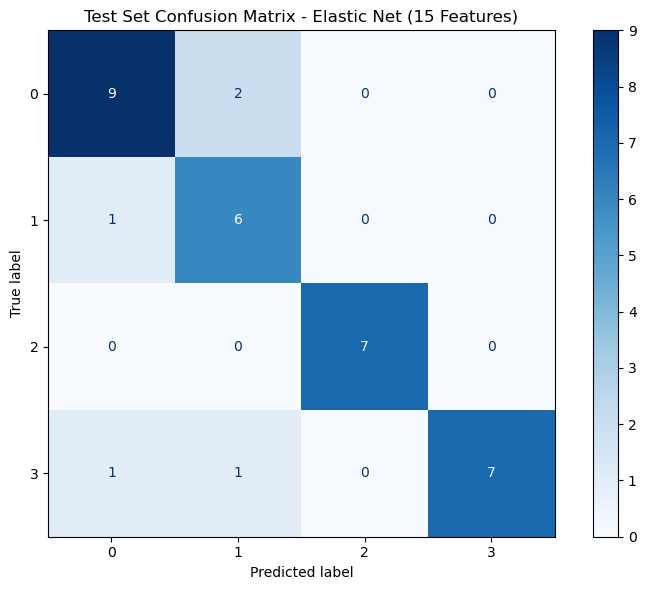

🏃 View run ElasticNet_15_Features_Corrected at: https://dagshub.com/PAWANPAHUNE/AI-Metagenomic-Pipeline-CIAT-Intern-.mlflow/#/experiments/3/runs/e1aac8cde6ef4dca8f8fa071a936d918
🧪 View experiment at: https://dagshub.com/PAWANPAHUNE/AI-Metagenomic-Pipeline-CIAT-Intern-.mlflow/#/experiments/3

✅ Execution Complete! Check DagsHub to view the results.


In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, f1_score, precision_score, 
                             recall_score, balanced_accuracy_score, 
                             confusion_matrix, ConfusionMatrixDisplay, make_scorer)

import mlflow
import mlflow.sklearn

# Suppress minor convergence warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. DATA PREPARATION (Strictly for Pre-Encoded Data)
# ==========================================
print("📂 Loading the Elite 15-Feature Dataset...")

df_compressed = pd.read_csv('/Users/pawanpahune/AI_Pipeline_Metagenomics/df_compression/compressed_df.csv')

# Separate features and target
X = df_compressed.drop(columns=['Target_Crop_Grouped'])

# FIX: Force as integer, strictly NO LabelEncoder used here.
y = df_compressed['Target_Crop_Grouped'].astype(int).values.ravel()

# Stratified Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.5, 
    random_state=42, 
    stratify=y  
)

print(f"✅ Data Ready: Training on {X_train.shape[1]} features.")

# ==========================================
# 2. DAGSHUB AUTH & MLFLOW SETUP
# ==========================================
print("🔐 Authenticating with DagsHub...")
os.environ["MLFLOW_TRACKING_USERNAME"] = os.getenv("MLFLOW_USERNAME")
os.environ["MLFLOW_TRACKING_PASSWORD"] = os.getenv("MLFLOW_TRACKING_PASSWORD")

TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI")
mlflow.set_tracking_uri(TRACKING_URI)
mlflow.set_experiment("Elastic_Net_Elite_15_Features")

# Enable Autologging for nested parameter tracking
mlflow.sklearn.autolog(log_models=True, log_input_examples=True)

# ==========================================
# 3. ELASTIC NET PIPELINE & OPTIMIZED GRID SEARCH
# ==========================================
pipeline = Pipeline([
    ('scaler', StandardScaler()), 
    ('clf', LogisticRegression(
        penalty='elasticnet', 
        solver='saga', 
        max_iter=10000, # Increased max_iter to ensure mathematical convergence
        random_state=42,
        class_weight='balanced'
    ))
])

# FIX: An optimized, finer grid specifically designed for low-dimensional data (15 features)
param_grid = {
    'clf__C': [0.001, 0.01, 0.1, 1.0, 10.0], # Finer regularization strengths
    'clf__l1_ratio': [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0] # Granular L1/L2 mixing
}

# Define rigorous scoring metrics
scoring_metrics = {
    'accuracy': make_scorer(accuracy_score),
    'f1_weighted': make_scorer(f1_score, average='weighted'),
    'precision': make_scorer(precision_score, average='weighted', zero_division=0),
    'recall': make_scorer(recall_score, average='weighted'),
    'balanced_acc': make_scorer(balanced_accuracy_score)
}

# 5-Fold Stratified Cross Validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring=scoring_metrics,
    refit='f1_weighted', 
    return_train_score=True,
    n_jobs=-1,
    verbose=1
)

# ==========================================
# 4. TRAINING & EVALUATION
# ==========================================
print("🚀 Starting Grid Search (Tuning C and L1 Ratio)...")

with mlflow.start_run(run_name="ElasticNet_15_Features_Corrected"):
    
    # Train the model
    grid_search.fit(X_train, y_train)
    
    # Extract the winning model
    best_model = grid_search.best_estimator_
    print(f"\n⭐ Best Parameters Found: {grid_search.best_params_}")
    
    # ------------------------------------------
    # Evaluate Final Best Model on the Holdout Test Set
    # ------------------------------------------
    y_pred_test = best_model.predict(X_test)
    
    test_metrics = {
        "test_f1_weighted": f1_score(y_test, y_pred_test, average='weighted'),
        "test_precision": precision_score(y_test, y_pred_test, average='weighted', zero_division=0),
        "test_recall": recall_score(y_test, y_pred_test, average='weighted'),
        "test_balanced_acc": balanced_accuracy_score(y_test, y_pred_test)
    }
    
    # Log the final test metrics explicitly
    mlflow.log_metrics(test_metrics)
    
    print("\n📊 Final Holdout Test Performance:")
    for k, v in test_metrics.items():
        print(f"  - {k}: {v:.4f}")
        
    # ------------------------------------------
    # Generate & Log Confusion Matrix (FIXED)
    # ------------------------------------------
    cm = confusion_matrix(y_test, y_pred_test)
    
    # FIX: Directly use the model's classes since they are already integers 
    # No more inverse_transform errors!
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
    
    # Plot formatting
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(cmap='Blues', ax=ax, values_format='d') 
    plt.title("Test Set Confusion Matrix - Elastic Net (15 Features)")
    
    plt.tight_layout()
    
    # Log directly to MLflow and show locally
    mlflow.log_figure(fig, "evaluation_plots/confusion_matrix.png")
    plt.show()

print("\n✅ Execution Complete! Check DagsHub to view the results.")